# Clasificación textual supervisada 

Este notebook construye el baseline supervisado del TFM: `TF-IDF + LogisticRegression`. La diferencia respecto a una versión inicial demasiado limpia es que ahora el dataset contiene textos breves, publicaciones ambiguas, vocabulario compartido, nombres propios, hashtags cruzados, ruido social y una pequeña proporción de etiquetas ruidosas.


## 1. Carga del dataset


In [97]:
import re
from collections import Counter
from itertools import combinations
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

DATA_PATH = Path("data/posts.csv")
REQUIRED_COLUMNS = ["id", "descripcion", "hashtags", "categoria"]
OPTIONAL_COLUMNS = [
    "categoria_generadora",
    "categoria_secundaria",
    "es_ambiguo",
    "tipo_post",
    "nivel_ruido",
    "etiqueta_ruidosa",
    "entidades",
]
MODELS_DIR = Path("models")
TEXT_CLASSIFIER_PATH = MODELS_DIR / "clasificador_textual_tfidf.joblib"
PIPELINE_TEXTUAL_PATH = MODELS_DIR / "pipeline_textual.pkl"
TEST_SIZE = 0.30
RANDOM_STATE = 42
TOP_N_TERMS = 12
TOP_N_WORDS = 25

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_colwidth", 140)


In [98]:
df = pd.read_csv(DATA_PATH, encoding="utf-8")

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias en el CSV: {missing_columns}")

available_optional_columns = [column for column in OPTIONAL_COLUMNS if column in df.columns]
df = df[REQUIRED_COLUMNS + available_optional_columns].copy()

print(f"Archivo cargado correctamente desde: {DATA_PATH}")
print(f"Número total de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")
print(f"Columnas opcionales detectadas: {available_optional_columns}")
display(df.head())


Archivo cargado correctamente desde: data\posts.csv
Número total de registros: 11000
Número de variables: 11
Columnas opcionales detectadas: ['categoria_generadora', 'categoria_secundaria', 'es_ambiguo', 'tipo_post', 'nivel_ruido', 'etiqueta_ruidosa', 'entidades']


,id,descripcion,hashtags,categoria,categoria_generadora,categoria_secundaria,es_ambiguo,tipo_post,nivel_ruido,etiqueta_ruidosa,entidades
0,1,plan improvisado: despues del gym cayo MasterChef porque el cuerpo lo pidio random pero necesario,#cocina #partido,deporte,deporte,cocina,True,micro,bajo,False,MasterChef
1,2,mini update: vuelo temprano con cafe dudoso sin filtros y con prisa 🎸,#gymbro #escapada #top,viajes,viajes,NaN,False,short,alto,False,NaN
2,3,vuelo temprano con cafe dudoso en Londres con camara,#Travel,viajes,viajes,NaN,False,short,bajo,False,NaN
3,4,"vibe de hoy: baño rapido antes de comer, que locura jajaja",#Random#Verano,playa,playa,NaN,False,short,alto,False,NaN
4,5,"vibe de hoy: brisa salada y cero prisa, ns q decir jaja",#sol,playa,playa,NaN,False,short,bajo,False,NaN


## 2. Análisis exploratorio de datos

El EDA se usa aquí como una herramienta de diagnóstico experimental. Si el dataset fuera perfectamente separable, el baseline TF-IDF tendría un comportamiento artificialmente alto y las conclusiones sobre embeddings y recomendación serían débiles. Por eso se comprueban distribución, longitud, ruido, ambigüedad, vocabulario compartido y similitud entre categorías antes de entrenar.


In [99]:
print("Valores nulos por columna:")
display(df.isna().sum().to_frame("nulos"))

class_counts = df["categoria"].value_counts().sort_index()
class_distribution = pd.DataFrame(
    {
        "registros": class_counts,
        "porcentaje": (class_counts / len(df) * 100).round(2),
    }
)

print("Distribución de registros por categoría:")
display(class_distribution)

metadata_rows = []
if "es_ambiguo" in df.columns:
    metadata_rows.append({"indicador": "posts_ambiguos", "valor": df["es_ambiguo"].mean()})
if "etiqueta_ruidosa" in df.columns:
    metadata_rows.append({"indicador": "etiquetas_ruidosas", "valor": df["etiqueta_ruidosa"].mean()})
if "nivel_ruido" in df.columns:
    for nivel, proporcion in df["nivel_ruido"].value_counts(normalize=True).sort_index().items():
        metadata_rows.append({"indicador": f"ruido_{nivel}", "valor": proporcion})

if metadata_rows:
    metadata_df = pd.DataFrame(metadata_rows)
    metadata_df["valor"] = (metadata_df["valor"] * 100).round(2)
    display(metadata_df.rename(columns={"valor": "porcentaje"}))


Valores nulos por columna:


,nulos
id,0
descripcion,311
hashtags,1975
categoria,0
categoria_generadora,0
categoria_secundaria,6332
es_ambiguo,0
tipo_post,0
nivel_ruido,0
etiqueta_ruidosa,0


Distribución de registros por categoría:


,registros,porcentaje
categoria,,
animales,1057,9.61
coches,1272,11.56
cocina,1236,11.24
deporte,1279,11.63
musica,1549,14.08
playa,1599,14.54
viajes,1930,17.55
videojuegos,1078,9.80


,indicador,porcentaje
0,posts_ambiguos,42.44
1,etiquetas_ruidosas,3.60
2,ruido_alto,17.05
3,ruido_bajo,49.30
4,ruido_medio,33.65


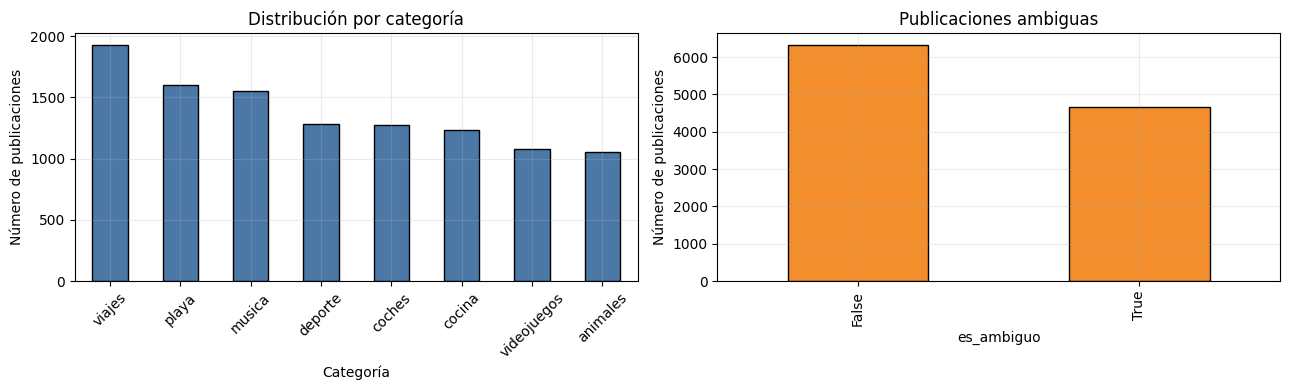

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_counts.sort_values(ascending=False).plot(
    kind="bar",
    color="#4C78A8",
    edgecolor="black",
    ax=axes[0],
)
axes[0].set_title("Distribución por categoría")
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Número de publicaciones")
axes[0].tick_params(axis="x", rotation=45)

if "es_ambiguo" in df.columns:
    df["es_ambiguo"].value_counts().sort_index().plot(
        kind="bar",
        color="#F28E2B",
        edgecolor="black",
        ax=axes[1],
    )
    axes[1].set_title("Publicaciones ambiguas")
    axes[1].set_xlabel("es_ambiguo")
    axes[1].set_ylabel("Número de publicaciones")
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()


La distribución no busca ser perfectamente uniforme. Un desbalance moderado es aceptable porque se parece más a datos de uso real. Lo importante es que ninguna clase domine por completo y que existan zonas de solapamiento capaces de generar errores interpretables.


In [101]:
df["texto_original"] = (
    df["descripcion"].fillna("").astype(str).str.strip()
    + " "
    + df["hashtags"].fillna("").astype(str).str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()

df["longitud_caracteres"] = df["texto_original"].str.len()
df["longitud_palabras"] = df["texto_original"].apply(lambda text: len(text.split()))

display(df[["longitud_caracteres", "longitud_palabras"]].describe().round(2))
print(f"Publicaciones sin descripción ni hashtags: {(df['texto_original'].str.len() == 0).sum()}")

if "tipo_post" in df.columns:
    display(df["tipo_post"].value_counts().rename_axis("tipo_post").reset_index(name="n_posts"))


,longitud_caracteres,longitud_palabras
count,11000.00,11000.00
mean,102.17,17.34
std,44.54,7.69
min,0.00,0.00
25%,71.00,12.00
50%,102.00,17.00
75%,129.00,22.00
max,384.00,56.00


Publicaciones sin descripción ni hashtags: 127


,tipo_post,n_posts
0,short,4638
1,medium,3507
2,micro,1749
3,long,977
4,outlier,129


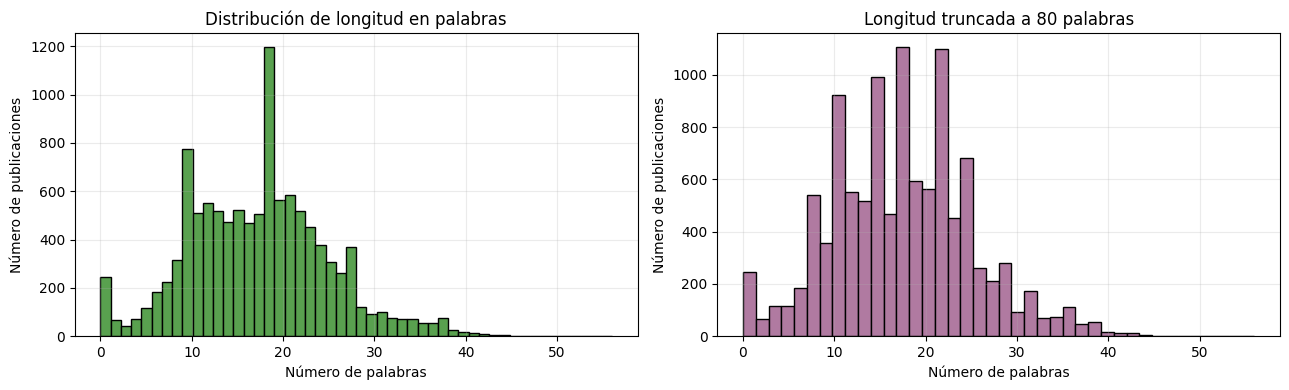

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["longitud_palabras"].plot(
    kind="hist",
    bins=50,
    color="#59A14F",
    edgecolor="black",
    ax=axes[0],
)
axes[0].set_title("Distribución de longitud en palabras")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Número de publicaciones")

df["longitud_palabras"].clip(upper=80).plot(
    kind="hist",
    bins=40,
    color="#B07AA1",
    edgecolor="black",
    ax=axes[1],
)
axes[1].set_title("Longitud truncada a 80 palabras")
axes[1].set_xlabel("Número de palabras")
axes[1].set_ylabel("Número de publicaciones")

plt.tight_layout()
plt.show()


La variabilidad de longitud introduce dificultad real: un texto como "top god" contiene poca señal, mientras que un post largo puede mezclar varias señales y generar una etiqueta dominante discutible.


In [103]:
def preprocesar_texto(texto: str) -> str:
    texto = str(texto).lower()
    texto = texto.replace("#", " ")
    texto = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


df["texto_limpio"] = df["texto_original"].apply(preprocesar_texto)
df["longitud_limpia_palabras"] = df["texto_limpio"].apply(lambda text: len(text.split()))

print(f"Publicaciones sin señal textual tras preprocesamiento: {(df['texto_limpio'].str.len() == 0).sum()}")
display(df[["descripcion", "hashtags", "categoria", "texto_limpio"]].sample(8, random_state=RANDOM_STATE))


Publicaciones sin señal textual tras preprocesamiento: 127


,descripcion,hashtags,categoria,texto_limpio
107,random vibe de hoy: perro mirando la comida con demasiada fe; luego porque a veecs sale bien sin pensarlo y acabamos hablando de Luna 🔥,#PetFriendly,animales,random vibe de hoy perro mirando la comida con demasiada fe luego porque a veecs sale bien sin pensarlo y acabamos hablando de luna petf...
5484,"despues de mil vueltas, zapatillas en el maletero y plan de ultima hora muy de hoy 🚗",#Garaje #Racing #Entreno,coches,despues de mil vueltas zapatillas en el maletero y plan de ultima hora muy de hoy garaje racing entreno
6998,domingo raro y chiringuito lleno pero la musica estaba increible asi y bueno,#costa #festival,playa,domingo raro y chiringuito lleno pero la musica estaba increible asi y bueno costa festival
3984,nadie me preparo para escapada express con maleta pequeña en Cadiz con maleta; con ganas de repetir y,#Top #Viajes,viajes,nadie me preparo para escapada express con maleta pequeña en cadiz con maleta con ganas de repetir y top viajes
3111,me desperte pensando en esto: cancion triste para un plan feliz con una playlist random de fondo no puedo mas 🍜,#live,musica,me desperte pensando en esto cancion triste para un plan feliz con una playlist random de fondo no puedo mas live
4040,literal viaje de finde para ver atardecer junto al mar en Gran Canaria,#Atardecer,playa,literal viaje de finde para ver atardecer junto al mar en gran canaria atardecer
3013,"betis y arroz, ns q decir jaja random ☀️ xd",#random,deporte,betis y arroz ns q decir jaja random xd random
6607,"no se como explicar esto pero stream de minecraft con playlist de aitana y chat imposible, mientras cae la tarde asi si xd ⚽",#Pop #Friends #FIFA #Urbano,videojuegos,no se como explicar esto pero stream de minecraft con playlist de aitana y chat imposible mientras cae la tarde asi si xd pop friends fi...


,palabra,frecuencia
0,plan,2129
1,hoy,2002
2,random,1765
3,despues,1688
4,fondo,1166
5,cero,1089
6,literalmente,1075
7,top,1073
8,playlist,1070
9,demasiado,1026


Palabras presentes en al menos tres categorías:


,palabra,n_categorias,categorias
29,acabamos,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos
183,aesthetic,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos
12,amsterdam,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos
128,aparecio,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos
38,asi,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos
159,barcelona,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos
8,bastante,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos
104,bateria,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos
141,berlin,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos
57,bien,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos


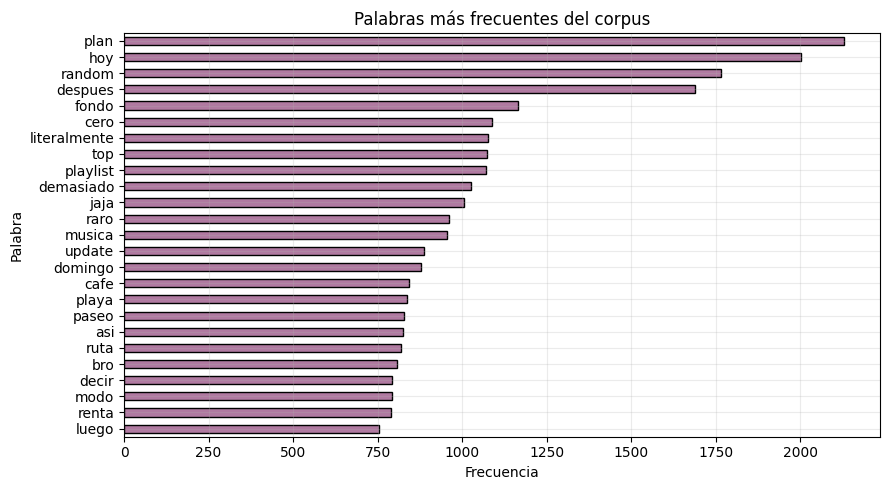

In [104]:
SPANISH_STOPWORDS = {
    "a", "al", "algo", "ante", "antes", "como", "con", "contra", "cual", "cuando",
    "de", "del", "desde", "donde", "durante", "e", "el", "ella", "ellas", "ellos",
    "en", "entre", "era", "eran", "es", "esa", "esas", "ese", "eso", "esos", "esta",
    "estaba", "estaban", "estado", "estan", "estar", "estas", "este", "esto", "estos",
    "fue", "ha", "hay", "he", "la", "las", "le", "les", "lo", "los", "mas", "me",
    "mi", "mis", "mucho", "muy", "ni", "no", "nos", "o", "para", "pero", "por",
    "que", "se", "sin", "sobre", "su", "sus", "tambien", "tan", "te", "tiene",
    "todo", "tras", "tu", "un", "una", "unas", "uno", "unos", "y", "ya",
}

tokens = []
tokens_by_category = {}
for categoria, textos in df.groupby("categoria")["texto_limpio"]:
    category_tokens = []
    for texto in textos:
        category_tokens.extend(
            token for token in texto.split()
            if token not in SPANISH_STOPWORDS and len(token) > 2
        )
    tokens.extend(category_tokens)
    tokens_by_category[categoria] = Counter(category_tokens)

frecuencias_globales = pd.DataFrame(
    Counter(tokens).most_common(TOP_N_WORDS),
    columns=["palabra", "frecuencia"],
)
display(frecuencias_globales)

token_categories = {}
for categoria, counter in tokens_by_category.items():
    for token, frecuencia in counter.items():
        if frecuencia >= 5:
            token_categories.setdefault(token, set()).add(categoria)

vocabulario_compartido = pd.DataFrame(
    [
        {"palabra": token, "n_categorias": len(categorias), "categorias": " | ".join(sorted(categorias))}
        for token, categorias in token_categories.items()
        if len(categorias) >= 3
    ]
).sort_values(["n_categorias", "palabra"], ascending=[False, True]).head(30)

print("Palabras presentes en al menos tres categorías:")
display(vocabulario_compartido)

ax = frecuencias_globales.sort_values("frecuencia").plot(
    kind="barh",
    x="palabra",
    y="frecuencia",
    legend=False,
    color="#B07AA1",
    edgecolor="black",
)
ax.set_title("Palabras más frecuentes del corpus")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Palabra")
plt.tight_layout()
plt.show()


### Similitud léxica intra e inter categoría

Para detectar si el dataset sigue siendo demasiado fácil, se calcula una similitud coseno sobre TF-IDF. Si las categorías fueran limpias y aisladas, la similitud intra-categoría quedaría muy por encima de la inter-categoría. En un corpus más realista, ambas distribuciones se acercan y aparecen pares temáticos naturalmente próximos.


In [105]:
def sparse_pair_cosine(matrix, indices_a, indices_b):
    return np.asarray(matrix[indices_a].multiply(matrix[indices_b]).sum(axis=1)).ravel()


df_eda = df[df["texto_limpio"].str.len() > 0].copy().reset_index(drop=True)
vectorizer_eda = TfidfVectorizer(
    min_df=3,
    max_df=0.82,
    max_features=12_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
)
X_eda = vectorizer_eda.fit_transform(df_eda["texto_limpio"])
rng = np.random.default_rng(RANDOM_STATE)

indices_por_categoria = {
    categoria: df_eda.index[df_eda["categoria"].eq(categoria)].to_numpy()
    for categoria in sorted(df_eda["categoria"].unique())
}

filas_intra = []
for categoria, indices in indices_por_categoria.items():
    n_pairs = min(1600, max(200, len(indices)))
    left = rng.choice(indices, size=n_pairs, replace=True)
    right = rng.choice(indices, size=n_pairs, replace=True)
    valid = left != right
    sims = sparse_pair_cosine(X_eda, left[valid], right[valid])
    filas_intra.append(
        {
            "categoria": categoria,
            "n_posts": len(indices),
            "similitud_intra_media": sims.mean(),
            "p90": np.percentile(sims, 90),
        }
    )

filas_inter = []
for categoria_a, categoria_b in combinations(indices_por_categoria.keys(), 2):
    indices_a = indices_por_categoria[categoria_a]
    indices_b = indices_por_categoria[categoria_b]
    n_pairs = min(800, len(indices_a), len(indices_b))
    left = rng.choice(indices_a, size=n_pairs, replace=True)
    right = rng.choice(indices_b, size=n_pairs, replace=True)
    sims = sparse_pair_cosine(X_eda, left, right)
    filas_inter.append(
        {
            "categoria_a": categoria_a,
            "categoria_b": categoria_b,
            "similitud_inter_media": sims.mean(),
            "p90": np.percentile(sims, 90),
        }
    )

df_similitud_intra = pd.DataFrame(filas_intra).sort_values("similitud_intra_media", ascending=False)
df_similitud_inter = pd.DataFrame(filas_inter).sort_values("similitud_inter_media", ascending=False)

similitud_intra_global = df_similitud_intra["similitud_intra_media"].mean()
similitud_inter_global = df_similitud_inter["similitud_inter_media"].mean()
separacion_intra_inter = similitud_intra_global - similitud_inter_global

display(df_similitud_intra.round(4))
print("Pares inter-categoría más cercanos:")
display(df_similitud_inter.head(12).round(4))
print(f"Similitud intra global: {similitud_intra_global:.4f}")
print(f"Similitud inter global: {similitud_inter_global:.4f}")
print(f"Brecha intra-inter: {separacion_intra_inter:.4f}")


,categoria,n_posts,similitud_intra_media,p90
7,videojuegos,1064,0.0532,0.1422
0,animales,1052,0.0498,0.1165
5,playa,1571,0.0475,0.1109
1,coches,1256,0.0449,0.1022
2,cocina,1222,0.0419,0.0971
3,deporte,1268,0.0407,0.0913
4,musica,1528,0.0375,0.0766
6,viajes,1912,0.0366,0.0910


Pares inter-categoría más cercanos:


,categoria_a,categoria_b,similitud_inter_media,p90
25,playa,viajes,0.0274,0.0672
4,animales,playa,0.0259,0.0677
24,musica,videojuegos,0.0252,0.0683
11,coches,viajes,0.0241,0.0614
13,cocina,deporte,0.0240,0.0597
3,animales,musica,0.0237,0.0674
18,deporte,musica,0.0235,0.0550
5,animales,viajes,0.0233,0.0592
23,musica,viajes,0.0230,0.0589
22,musica,playa,0.0223,0.0553


Similitud intra global: 0.0440
Similitud inter global: 0.0214
Brecha intra-inter: 0.0226


## 3. Metodología supervisada

El modelo clásico se entrena con textos normalizados. Esta decisión favorece a TF-IDF porque reduce variantes superficiales, pero también elimina señales sociales como emojis, puntuación o estilo. Por tanto, si aun así aparecen errores, esos errores son útiles para justificar que el problema no es meramente una clasificación trivial por palabras clave.


In [106]:
df_modelo = df[df["texto_limpio"].str.len() > 0].copy()

print(f"Registros originales: {len(df)}")
print(f"Registros utilizados para modelado: {len(df_modelo)}")
print(f"Registros excluidos por texto vacío: {len(df) - len(df_modelo)}")

y = df_modelo["categoria"]
train_indices, test_indices = train_test_split(
    df_modelo.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train = df_modelo.loc[train_indices, "texto_limpio"]
X_test = df_modelo.loc[test_indices, "texto_limpio"]
y_train = df_modelo.loc[train_indices, "categoria"]
y_test = df_modelo.loc[test_indices, "categoria"]

split_distribution = pd.DataFrame(
    {
        "train": y_train.value_counts().sort_index(),
        "test": y_test.value_counts().sort_index(),
    }
)
split_distribution["train_%"] = (split_distribution["train"] / len(y_train) * 100).round(2)
split_distribution["test_%"] = (split_distribution["test"] / len(y_test) * 100).round(2)
display(split_distribution)


Registros originales: 11000
Registros utilizados para modelado: 10873
Registros excluidos por texto vacío: 127


,train,test,train_%,test_%
categoria,,,,
animales,736,316,9.67,9.69
coches,879,377,11.55,11.56
cocina,855,367,11.23,11.25
deporte,888,380,11.67,11.65
musica,1070,458,14.06,14.04
playa,1100,471,14.45,14.44
viajes,1338,574,17.58,17.60
videojuegos,745,319,9.79,9.78


In [107]:
vectorizer = TfidfVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Documentos de entrenamiento: {X_train_tfidf.shape[0]}")
print(f"Documentos de prueba: {X_test_tfidf.shape[0]}")
print(f"Tamaño del vocabulario aprendido: {X_train_tfidf.shape[1]}")


Documentos de entrenamiento: 7611
Documentos de prueba: 3262
Tamaño del vocabulario aprendido: 8532


In [108]:
model = LogisticRegression(max_iter=1200, random_state=RANDOM_STATE)
model.fit(X_train_tfidf, y_train)

print("Modelo entrenado correctamente.")
print(f"Clases aprendidas: {list(model.classes_)}")


Modelo entrenado correctamente.
Clases aprendidas: ['animales', 'coches', 'cocina', 'deporte', 'musica', 'playa', 'viajes', 'videojuegos']


In [109]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

pipeline_textual = Pipeline(
    steps=[
        ("tfidf", vectorizer),
        ("clasificador", model),
    ]
)

artefacto_clasificador = {
    "pipeline": pipeline_textual,
    "vectorizer": vectorizer,
    "model": model,
    "classes": list(model.classes_),
    "text_column": "texto_limpio",
    "data_path": str(DATA_PATH),
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "preprocessing_note": "El pipeline espera texto ya normalizado con preprocesar_texto.",
    "available_metadata_columns": available_optional_columns,
}

joblib.dump(artefacto_clasificador, TEXT_CLASSIFIER_PATH)
joblib.dump(pipeline_textual, PIPELINE_TEXTUAL_PATH)

print(f"Clasificador textual exportado en: {TEXT_CLASSIFIER_PATH}")
print(f"Pipeline compatible exportado en: {PIPELINE_TEXTUAL_PATH}")


Clasificador textual exportado en: models\clasificador_textual_tfidf.joblib
Pipeline compatible exportado en: models\pipeline_textual.pkl


In [110]:
feature_names = vectorizer.get_feature_names_out()
top_terms_rows = []

for class_index, categoria in enumerate(model.classes_):
    top_indices = model.coef_[class_index].argsort()[-TOP_N_TERMS:][::-1]
    for posicion, term_index in enumerate(top_indices, start=1):
        top_terms_rows.append(
            {
                "categoria": categoria,
                "posicion": posicion,
                "termino": feature_names[term_index],
                "coeficiente": round(float(model.coef_[class_index][term_index]), 4),
            }
        )

top_terms_df = pd.DataFrame(top_terms_rows)
display(top_terms_df)


,categoria,posicion,termino,coeficiente
0,animales,1,catlife,3.2875
1,animales,2,paseo,3.1872
2,animales,3,veterinario,3.0166
3,animales,4,mascotas,2.9440
4,animales,5,parque,2.9366
...,...,...,...,...
91,videojuegos,8,setup,2.4926
92,videojuegos,9,gamer,2.3378
93,videojuegos,10,fortnite,2.1579
94,videojuegos,11,modo carrera,2.0963


## 4. Evaluación

La evaluación se realiza sobre el conjunto de prueba. Además de métricas agregadas, se analizan errores, confianza y relación con los metadatos del generador. Esto ayuda a separar dos fenómenos: fallos del modelo y ambigüedad real del dato.


In [111]:
y_pred = model.predict(X_test_tfidf)
probabilidades = model.predict_proba(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

metricas_globales = pd.DataFrame(
    {
        "métrica": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
        "valor": [accuracy, precision_macro, recall_macro, f1_macro],
    }
)
display(metricas_globales.round(4))

test_results_columns = [
    column for column in [
        "id", "descripcion", "hashtags", "categoria", "categoria_generadora",
        "categoria_secundaria", "es_ambiguo", "tipo_post", "nivel_ruido",
        "etiqueta_ruidosa", "entidades", "texto_limpio",
    ] if column in df_modelo.columns
]
test_results = df_modelo.loc[test_indices, test_results_columns].copy()
test_results["prediccion"] = y_pred
test_results["confianza"] = probabilidades.max(axis=1)
test_results["acierto"] = test_results["categoria"].to_numpy() == y_pred

print("Classification report:")
print(classification_report(y_test, y_pred, zero_division=0))


,métrica,valor
0,accuracy,0.8038
1,precision_macro,0.8157
2,recall_macro,0.8114
3,f1_macro,0.8130


Classification report:
              precision    recall  f1-score   support

    animales       0.88      0.83      0.85       316
      coches       0.86      0.84      0.85       377
      cocina       0.84      0.85      0.84       367
     deporte       0.80      0.81      0.80       380
      musica       0.76      0.71      0.73       458
       playa       0.77      0.86      0.81       471
      viajes       0.73      0.73      0.73       574
 videojuegos       0.90      0.87      0.88       319

    accuracy                           0.80      3262
   macro avg       0.82      0.81      0.81      3262
weighted avg       0.80      0.80      0.80      3262



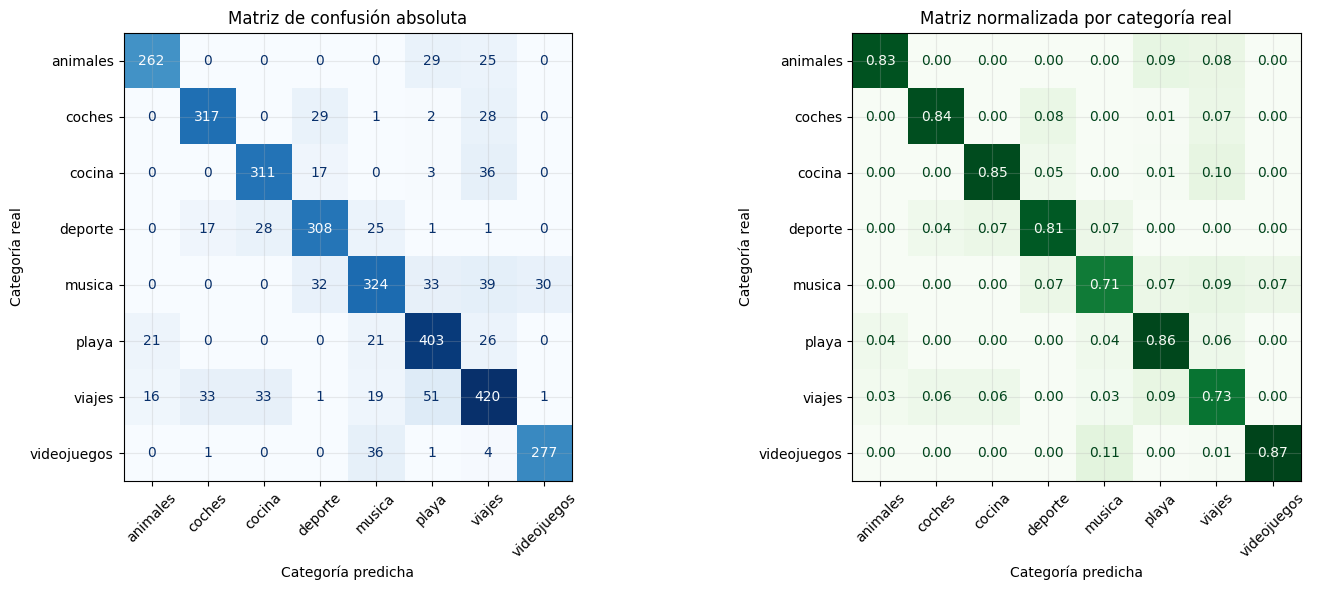

In [112]:
labels = list(model.classes_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels,
    display_labels=labels,
    cmap="Blues",
    xticks_rotation=45,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Matriz de confusión absoluta")
axes[0].set_xlabel("Categoría predicha")
axes[0].set_ylabel("Categoría real")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels,
    display_labels=labels,
    normalize="true",
    values_format=".2f",
    cmap="Greens",
    xticks_rotation=45,
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Matriz normalizada por categoría real")
axes[1].set_xlabel("Categoría predicha")
axes[1].set_ylabel("Categoría real")

plt.tight_layout()
plt.show()


In [113]:
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
class_report_df = report_df.loc[labels, ["precision", "recall", "f1-score", "support"]].copy()
class_report_df[["precision", "recall", "f1-score"]] = class_report_df[
    ["precision", "recall", "f1-score"]
].round(4)
class_report_df["support"] = class_report_df["support"].astype(int)
display(class_report_df.sort_values("f1-score", ascending=True))

if "es_ambiguo" in test_results.columns:
    print("Exactitud por ambigüedad:")
    display(test_results.groupby("es_ambiguo")["acierto"].agg(["count", "mean"]).rename(columns={"mean": "accuracy"}).round(4))

if "nivel_ruido" in test_results.columns:
    print("Exactitud por nivel de ruido:")
    display(test_results.groupby("nivel_ruido")["acierto"].agg(["count", "mean"]).rename(columns={"mean": "accuracy"}).round(4))

if "etiqueta_ruidosa" in test_results.columns:
    print("Exactitud según etiqueta ruidosa simulada:")
    display(test_results.groupby("etiqueta_ruidosa")["acierto"].agg(["count", "mean"]).rename(columns={"mean": "accuracy"}).round(4))


,precision,recall,f1-score,support
viajes,0.7254,0.7317,0.7285,574
musica,0.7606,0.7074,0.7330,458
deporte,0.7959,0.8105,0.8031,380
playa,0.7706,0.8556,0.8109,471
cocina,0.8360,0.8474,0.8417,367
coches,0.8614,0.8408,0.8510,377
animales,0.8763,0.8291,0.8520,316
videojuegos,0.8994,0.8683,0.8836,319


Exactitud por ambigüedad:


,count,accuracy
es_ambiguo,,
False,1884,0.939
True,1378,0.619


Exactitud por nivel de ruido:


,count,accuracy
nivel_ruido,,
alto,529,0.7694
bajo,1639,0.8096
medio,1094,0.8117


Exactitud según etiqueta ruidosa simulada:


,count,accuracy
etiqueta_ruidosa,,
False,3152,0.8268
True,110,0.1455


In [114]:
cm = confusion_matrix(y_test, y_pred, labels=labels)
confusion_rows = []

for real_index, real_label in enumerate(labels):
    for pred_index, pred_label in enumerate(labels):
        if real_index != pred_index and cm[real_index, pred_index] > 0:
            confusion_rows.append(
                {
                    "categoria_real": real_label,
                    "categoria_predicha": pred_label,
                    "casos": int(cm[real_index, pred_index]),
                }
            )

confusiones_df = pd.DataFrame(confusion_rows).sort_values("casos", ascending=False)
display(confusiones_df.head(20))

errores = test_results[~test_results["acierto"]].sort_values("confianza", ascending=False)
print("Errores de alta confianza, útiles para discutir límites de TF-IDF:")
display(errores.head(12)[
    [
        column for column in [
            "descripcion", "hashtags", "categoria", "prediccion", "confianza",
            "categoria_secundaria", "es_ambiguo", "nivel_ruido", "etiqueta_ruidosa",
        ] if column in errores.columns
    ]
])


,categoria_real,categoria_predicha,casos
26,viajes,playa,51
16,musica,viajes,39
8,cocina,viajes,36
29,videojuegos,musica,36
23,viajes,cocina,33
15,musica,playa,33
22,viajes,coches,33
14,musica,deporte,32
17,musica,videojuegos,30
0,animales,playa,29


Errores de alta confianza, útiles para discutir límites de TF-IDF:


,descripcion,hashtags,categoria,prediccion,confianza,categoria_secundaria,es_ambiguo,nivel_ruido,etiqueta_ruidosa
3463,"paseo por la costa, muy de hoy",#atardecer #playa,musica,playa,0.969674,NaN,False,bajo,True
10865,se tenia que decir boss facil hasta que deja de serlo en Valencia con pantalla,#GTA #Update #FIFA,musica,videojuegos,0.963148,NaN,False,medio,True
6859,NaN,#Escapada,cocina,viajes,0.957276,viajes,True,bajo,False
7181,dabiz munoz: postre demasiado dulce y random pero necesario,#cena #fyp,viajes,cocina,0.944622,NaN,False,medio,True
7412,sol flojo pero planazo en Valencia con perro,#Sol,musica,playa,0.929824,NaN,False,medio,True
10484,"Bad Bunny aparecio en el plan: directo que suena mejor de lo esperado, en modo desconectar, playlist incluido",#spotify,playa,musica,0.925967,NaN,False,bajo,True
2665,"Lisboa aparecio en el plan: vuelo temprano con cafe dudoso, despues de una semana eterna, maleta incluido 🧳",#escapada #viajes #planazo,musica,viajes,0.921775,NaN,False,bajo,True
8367,"nadie me preparo para actualizacion rara pero trae cosas buenas, random pero necesario",#PlayStation #Random,musica,videojuegos,0.909496,NaN,False,bajo,True
4721,"Twitch apaarecio en el plan: setup medio ordenado para variar, sin filtros y con prisa, pantalla incluido",#twitch,musica,videojuegos,0.907255,NaN,False,medio,True
10064,"xd ramen aparecio en el plan: salsa rara que al final funciona, sin filtros y con prisa, pan incluido 🐶",#Receta #Cena,deporte,cocina,0.905350,NaN,False,alto,True


## 5. Pruebas cualitativas

Estas pruebas no sustituyen al test, pero sirven para inspeccionar casos que el TFM quiere discutir: mezcla de señales, entidades reales y expresiones cortas. Se preprocesan igual que el entrenamiento porque el pipeline TF-IDF se entrenó sobre `texto_limpio`.


In [115]:
pipeline = joblib.load(PIPELINE_TEXTUAL_PATH)

textos_prueba = [
    "jugando al FIFA escuchando Anuel",
    "viaje en coche por la costa",
    "cocinando mientras veo fútbol",
    "vacaciones con música y playa",
    "BMW aparcado frente al hotel en Ibiza",
    "top god random",
]

textos_prueba_limpios = [preprocesar_texto(texto) for texto in textos_prueba]
predicciones = pipeline.predict(textos_prueba_limpios)
probabilidades = pipeline.predict_proba(textos_prueba_limpios)
categorias = pipeline.classes_

for i, texto in enumerate(textos_prueba):
    print("=" * 90)
    print(f"TEXTO: {texto}")
    print(f"TEXTO LIMPIO: {textos_prueba_limpios[i]}")
    print(f"Categoría predicha: {predicciones[i]}")
    probs_ordenadas = sorted(zip(categorias, probabilidades[i]), key=lambda item: item[1], reverse=True)
    for categoria, prob in probs_ordenadas[:5]:
        print(f"  - {categoria:<15} -> {prob:.4f}")


TEXTO: jugando al FIFA escuchando Anuel
TEXTO LIMPIO: jugando al fifa escuchando anuel
Categoría predicha: musica
  - musica          -> 0.4816
  - videojuegos     -> 0.2844
  - viajes          -> 0.0508
  - deporte         -> 0.0401
  - playa           -> 0.0379
TEXTO: viaje en coche por la costa
TEXTO LIMPIO: viaje en coche por la costa
Categoría predicha: coches
  - coches          -> 0.4042
  - viajes          -> 0.3728
  - playa           -> 0.1531
  - musica          -> 0.0259
  - animales        -> 0.0148
TEXTO: cocinando mientras veo fútbol
TEXTO LIMPIO: cocinando mientras veo fútbol
Categoría predicha: videojuegos
  - videojuegos     -> 0.2448
  - musica          -> 0.2255
  - deporte         -> 0.1775
  - viajes          -> 0.0971
  - animales        -> 0.0888
TEXTO: vacaciones con música y playa
TEXTO LIMPIO: vacaciones con música y playa
Categoría predicha: playa
  - playa           -> 0.7331
  - viajes          -> 0.1812
  - animales        -> 0.0236
  - musica          ->

## 6. Conclusiones del baseline

El baseline TF-IDF sigue siendo útil como punto de partida: aprende asociaciones transparentes entre términos y categorías y permite inspeccionar coeficientes. Sin embargo, el dataset muestra límites que antes quedaban ocultos: nombres propios compartidos, hashtags cruzados, textos mínimos, ruido y publicaciones con más de una señal temática.

La conclusión metodológica es que una accuracy alta ya no basta. Hay que leer errores, confusiones y confianza para justificar el paso a embeddings y posteriormente a recomendación dinámica con diversidad.
